In [1]:
#import required Libaries
import os
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models

In [2]:
#use CPU only
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [3]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("marquis03/bdd100k-scenario-classification")

print("Path to dataset files:", path)

Path to dataset files: /Users/eniyamadden/.cache/kagglehub/datasets/marquis03/bdd100k-scenario-classification/versions/1


In [4]:
print(os.listdir(path))

['test', 'train', 'val']


In [5]:
train_path = os.path.join(path, "train")
print(os.listdir(train_path))

['city street', 'parking lot', 'highway', 'tunnel', 'residential', 'gas stations', 'unknown']


In [ ]:
import os
import hashlib
import pandas as pd

def get_file_hash(filepath, chunk_size=8192):
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()

def collect_image_paths(root_dir):
    rows = []
    class_names = sorted(os.listdir(root_dir))
    
    for label_name in class_names:
        class_dir = os.path.join(root_dir, label_name)
        if not os.path.isdir(class_dir):
            continue
            
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            if os.path.isfile(fpath):
                rows.append({
                    "filepath": fpath,
                    "label": label_name,
                    "filename": fname
                })
    return pd.DataFrame(rows)

train_df = collect_image_paths(os.path.join(path, "train"))
train_df["md5"] = train_df["filepath"].apply(get_file_hash)

dup_exact = train_df[train_df.duplicated("md5", keep=False)].sort_values("md5")
print("Number of exact duplicate files:", dup_exact.shape[0])
print(dup_exact.head(20))


#The exact same dataset was found in 2 lables

Number of exact duplicate files: 2
                                                filepath        label  \
39991  /Users/eniyamadden/.cache/kagglehub/datasets/m...  city street   
47793  /Users/eniyamadden/.cache/kagglehub/datasets/m...      highway   

                    filename                               md5  
39991  6e09762a-bab508de.jpg  2610db2b184b4ff1e22349a81ceb2571  
47793  559b242e-90cd7279.jpg  2610db2b184b4ff1e22349a81ceb2571  


In [7]:
duplicate_md5s = train_df[train_df.duplicated("md5", keep=False)]["md5"].unique()
print("Duplicate hash values:", duplicate_md5s)

Duplicate hash values: ['2610db2b184b4ff1e22349a81ceb2571']


In [ ]:
# loading and spliting the dataset for train/test/validation
from sklearn.model_selection import train_test_split

img_size = (224, 224)
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

#remove all duplicates by hashing
train_df = train_df.drop_duplicates(subset="md5", keep="first").reset_index(drop=True)

class_names = sorted(train_df["label"].unique())
class_to_index = {name: i for i, name in enumerate(class_names)}

train_df["label_idx"] = train_df["label"].map(class_to_index)


train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.3,
    stratify=train_df["label_idx"],
    random_state=42
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

test_df = collect_image_paths(os.path.join(path, "val"))
test_df["label_idx"] = test_df["label"].map(class_to_index)

# drop rows with labels not found in training classes, just in case
test_df = test_df.dropna(subset=["label_idx"]).reset_index(drop=True)
test_df["label_idx"] = test_df["label_idx"].astype(int)

def load_and_preprocess_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["filepath"].values,
        df["label_idx"].values
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# Final datasets

train_dataset = make_dataset(train_split_df, shuffle=True)
val_dataset = make_dataset(val_split_df, shuffle=False)
test_dataset = make_dataset(test_df, shuffle=False)

print("Train samples:", len(train_split_df))
print("Validation samples:", len(val_split_df))
print("Test samples:", len(test_df))
print("Classes:", class_names)



Train samples: 48903
Validation samples: 20959
Test samples: 10000
Classes: ['city street', 'gas stations', 'highway', 'parking lot', 'residential', 'tunnel', 'unknown']


In [17]:
# Build Resnet Block
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, filters, stride=1, l2= None):
        super().__init__()
        self.filters = filters
        self.stride = stride

        self.conv1 = layers.Conv2D(filters, 3, strides=stride, padding='same', kernel_regularizer=l2)
        self.bn1 = layers.BatchNormalization()

        self.conv2 = layers.Conv2D(filters, 3, strides=1, padding='same', kernel_regularizer=l2)
        self.bn2 = layers.BatchNormalization()
    

    def build(self, input_shape):
        if self.stride != 1 or input_shape[-1] != self.filters:
            self.shortcut = tf.keras.Sequential([
                layers.Conv2D(self.filters, 1, self.stride, padding='same'),
                layers.BatchNormalization()
            ])
        else:
            self.shortcut = lambda x: x   # identity

    def call(self, x):
        shortcut = self.shortcut(x)

        x = tf.nn.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))

        x = x + shortcut
        return tf.nn.relu(x)

In [18]:
# Build Resnet Model
def build_resnet(input_shape=(224,224,3), num_classes=7):
    l2 = regularizers.l2(1e-4)

    inputs = layers.Input(shape=input_shape)

    # Initial layer
    x = layers.Conv2D(64, 7, strides=2, padding='same', kernel_regularizer=l2)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # Residual stages
    # Stage 1
    x = ResidualBlock(64, stride=1, l2=l2)(x)
    x = ResidualBlock(64, stride=1, l2=l2)(x)

    # Stage 2
    x = ResidualBlock(128, stride=2, l2=l2)(x)
    x = ResidualBlock(128, stride=1, l2=l2)(x)

    # Stage 3
    x = ResidualBlock(256, stride=2, l2=l2)(x)
    x = ResidualBlock(256, stride=1, l2=l2)(x)

    # Stage 4
    x = ResidualBlock(512, stride=2, l2=l2)(x)
    x = ResidualBlock(512, stride=1, l2=l2)(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=l2
    )(x)

    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model

In [19]:
# Configuring the model howto learn
model = build_resnet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 64)   │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_8                │ (None, 56, 56, 64)     │        74,368 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_9                │ (None, 56, 56, 64)     │        74,368 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_10               │ (None, 28, 28, 128)    │       231,296 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_11               │ (None, 28, 28, 128)    │       296,192 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_12               │ (None, 14, 14, 256)    │       921,344 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_13               │ (None, 14, 14, 256)    │     1,182,208 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_14               │ (None, 7, 7, 512)      │     3,677,696 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_15               │ (None, 7, 7, 512)      │     4,723,712 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,257,479 (42.94 MB)

 Trainable params: 11,247,879 (42.91 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [20]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

Epoch 1/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 2472s 2s/step - accuracy: 0.6551 - loss: 1.2536 - val_accuracy: 0.6748 - val_loss: 1.2291
Epoch 2/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 2661s 2s/step - accuracy: 0.6956 - loss: 1.1070 - val_accuracy: 0.7149 - val_loss: 1.0111
Epoch 3/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 3008s 2s/step - accuracy: 0.7147 - loss: 1.0067 - val_accuracy: 0.5925 - val_loss: 1.4632
Epoch 4/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 3547s 2s/step - accuracy: 0.7254 - loss: 0.9276 - val_accuracy: 0.6773 - val_loss: 0.9662
Epoch 5/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 5152s 3s/step - accuracy: 0.7334 - loss: 0.8629 - val_accuracy: 0.6991 - val_loss: 0.9433
Epoch 6/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 4354s 3s/step - accuracy: 0.7455 - loss: 0.8039 - val_accuracy: 0.7198 - val_loss: 0.8946
Epoch 7/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 6515s 4s/step - accuracy: 0.7653 - loss: 0.7492 - val_accuracy: 0.7251 - val_loss: 1.0125
Epoch 8/10
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 16332s 11s/step - accuracy: 0.7900

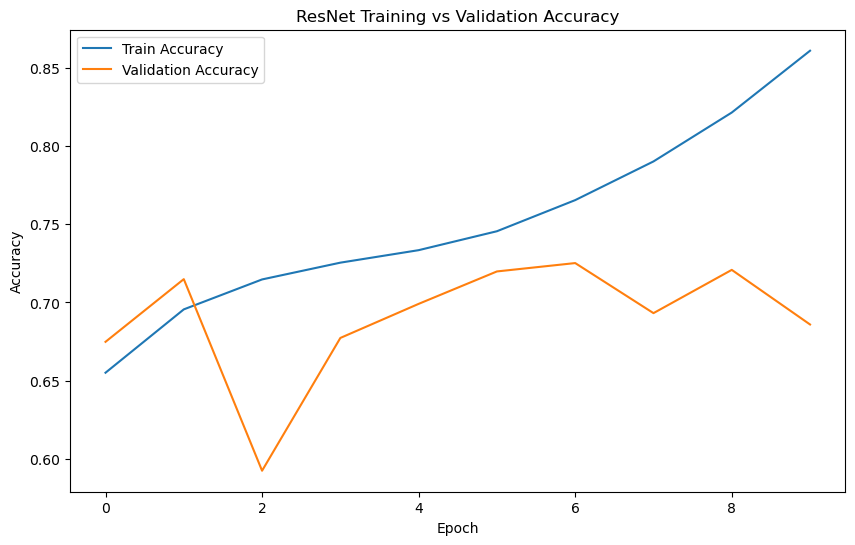

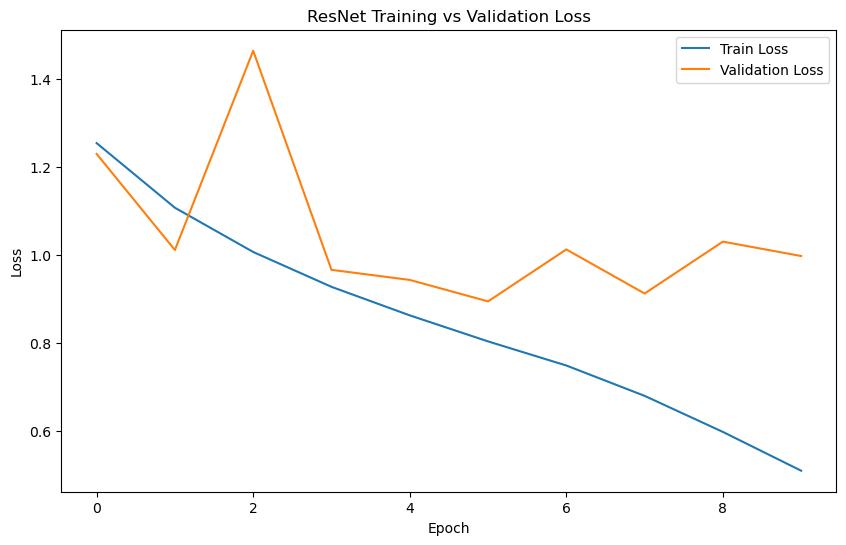

In [21]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

# Accuracy plot
plt.figure(figsize=(10,6))
plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
plt.plot(hist['epoch'], hist['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(10,6))
plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
plt.plot(hist['epoch'], hist['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet Training vs Validation Loss')
plt.legend()
plt.show()